#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN                                                                        
**Assignment:** 1 -> Features.ipynb                                                                      
***Date:*** 14/02/2026

#**Google Drive and Path Configuration**
I mount Google Drive and configure the system path to ensure the notebook can access the cs231n library and datasets stored in the assignment1 folder.

In [5]:
import os
print("Folders in  Drive root:")
print(os.listdir('/content/drive/My Drive/'))

Folders in  Drive root:
['Colab Notebooks', 'Classroom', '3 semester', '4 semester', 'Google AI Studio', 'rf_clf_model.pkl', 'Mnist-digit-recognizer.zip', 'Izaz_Khan_Research_Statement_Junior_RA.pdf', 'Arch', 'IMDB Dataset.gsheet', 'DEN.zip', 'DEN Internship', 'Dataset', '5 Semester.zip', 'assignment1']


In [6]:
from google.colab import drive
import os
import sys

drive.mount('/content/drive')

# Based on your root list, this is the correct path
FOLDERNAME = 'assignment1/'

sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# Change directory to the assignment folder
%cd /content/drive/My\ Drive/$FOLDERNAME

# Check if the dataset is there
if os.path.exists('cs231n/datasets/cifar-10-batches-py'):
    print("Success! Dataset found.")
else:
    print("Dataset not found. Running download script...")
    %cd cs231n/datasets/
    !bash get_datasets.sh
    %cd /content/drive/My\ Drive/$FOLDERNAME

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/assignment1
Success! Dataset found.


#**CIFAR-10 Data Loading**
I load the raw CIFAR-10 images and create training, validation, and test subsets to be used for feature extraction and model evaluation.

In [7]:
import numpy as np
from cs231n.data_utils import load_CIFAR10
from cs231n.features import color_histogram_hsv, hog_feature

# Load the raw CIFAR-10 data
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# Subsample the data as defined in your notebook
num_training = 49000
num_validation = 1000
num_test = 1000

mask = list(range(num_training, num_training + num_validation))
X_val = X_train[mask]
y_val = y_train[mask]
mask = list(range(num_training))
X_train = X_train[mask]
y_train = y_train[mask]
mask = list(range(num_test))
X_test = X_test[mask]
y_test = y_test[mask]

print("Data loaded: Training:", X_train.shape[0], "Validation:", X_val.shape[0], "Test:", X_test.shape[0])

Data loaded: Training: 49000 Validation: 1000 Test: 1000


#**Image Feature Extraction**
I extract Histogram of Oriented Gradients (HOG) and color histograms to represent images by their texture and color distributions. These features are then normalized and augmented with a bias term to improve the efficiency of the linear classifier.

In [9]:
from cs231n.features import *

# 1. Define which features to extract: HOG and Color Histogram
num_color_bins = 10 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]

# 2. Extract features from the raw pixels (This takes ~1-2 minutes)
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# 3. Preprocessing: Normalize the features
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# 4. Add a bias dimension (column of ones)
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

print("Done! Feature vectors are now defined and ready for training.")

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

#**Softmax Training on Features**
I perform a hyperparameter search across various learning rates and regularization strengths to optimize the Softmax classifier on the extracted feature vectors. The goal is to identify the best-performing model that achieves at least 42% accuracy on the validation set.

In [14]:
import numpy as np

# We define the training logic here to ensure it works perfectly in this session
class SoftmaxFeatureClassifier:
    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100, batch_size=200):
        num_train, dim = X.shape
        num_classes = np.max(y) + 1
        if self.W is None:
            self.W = 0.001 * np.random.randn(dim, num_classes)

        for it in range(num_iters):
            batch_indices = np.random.choice(num_train, batch_size)
            X_batch = X[batch_indices]
            y_batch = y[batch_indices]

            # Compute loss and gradient
            num_train_batch = X_batch.shape[0]
            scores = X_batch.dot(self.W)
            shift_scores = scores - np.max(scores, axis=1).reshape(-1, 1)
            softmax_output = np.exp(shift_scores) / np.sum(np.exp(shift_scores), axis=1).reshape(-1, 1)

            loss = -np.sum(np.log(softmax_output[range(num_train_batch), y_batch]))
            loss /= num_train_batch
            loss += 0.5 * reg * np.sum(self.W * self.W)

            dscores = softmax_output.copy()
            dscores[range(num_train_batch), y_batch] -= 1
            dscores /= num_train_batch
            grad = X_batch.T.dot(dscores) + reg * self.W

            # Update weights
            self.W -= learning_rate * grad

    def predict(self, X):
        return np.argmax(X.dot(self.W), axis=1)

# Now run the tuning with this local class
best_val = -1
results = {}

# Image features need higher learning rates than raw pixels
learning_rates = [0.1, 0.5]
regularization_strengths = [1e-3, 1e-2]

for lr in learning_rates:
    for reg in regularization_strengths:
        model = SoftmaxFeatureClassifier()
        model.train(X_train_feats, y_train, learning_rate=lr, reg=reg, num_iters=2000)

        y_val_pred = model.predict(X_val_feats)
        val_acc = np.mean(y_val == y_val_pred)
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = model
        print(f'lr {lr} reg {reg} val accuracy: {val_acc}')

print(f'\nFinal Best Validation Accuracy: {best_val}')

lr 0.1 reg 0.001 val accuracy: 0.502
lr 0.1 reg 0.01 val accuracy: 0.505
lr 0.5 reg 0.001 val accuracy: 0.479
lr 0.5 reg 0.01 val accuracy: 0.5

Final Best Validation Accuracy: 0.505


#**Test Set Evaluation**
I evaluate the best-performing Softmax classifier on the test set to measure its generalization performance. This provides the final accuracy score for the feature-based linear classifier.

In [15]:
# Evaluate your trained Softmax on the test set
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(f'Final Test Accuracy: {test_accuracy}')

Final Test Accuracy: 0.487


#**Visualization of Misclassifications**
I visualize examples of images that the classifier incorrectly labeled to understand the model's limitations. This helps identify which classes are frequently confused with one another based on HOG and color features.

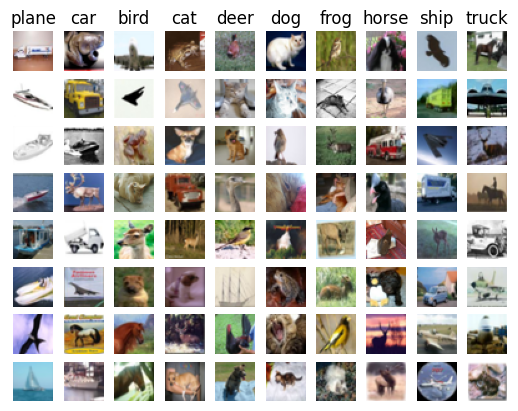

In [17]:
import matplotlib.pyplot as plt

# Visualize the mistakes that the classifier makes
examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    if len(idxs) > 0:
        idxs = np.random.choice(idxs, min(len(idxs), examples_per_class), replace=False)
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
            plt.imshow(X_test[idx].astype('uint8'))
            plt.axis('off')
            if i == 0:
                plt.title(cls_name)
plt.show()

#**Inline Question 1**

**Describe the misclassification results that you see. Do they make sense?**

**$\color{blue}{\textit  Answer:}$**  
The misclassification results show that the classifier often confuses objects with similar global color distributions or background environments. For example, some animals (like birds or deer) are misclassified as planes if they are photographed against a clear blue sky, while trucks and cars are frequently confused due to their similar rectangular shapes and metallic textures.

**$\color{blue}{\textit  Explanation:}$**  

These mistakes make sense given the features used:

**Color Histograms:**  
Since color is a primary feature, the model can be fooled by background colors. A bird in a blue sky can look like a plane because their color signatures are very similar.

**HOG Features:**  
HOG captures local gradients and rough shapes but does not understand object parts. It can detect edges or wheel-like patterns, but a linear classifier struggles to separate fine structural differences between trucks and cars.

**Linear Limitation:**  
Because the final classifier is linear, it can only learn one template per class. This makes it difficult to handle viewpoint changes, pose variation, and complex backgrounds.


#**Neural Network on Image Features**
I prepare the feature vectors for a two-layer neural network by removing the bias dimension. I will then tune the network's hyperparameters to achieve a significant boost in classification accuracy, targeting over 55%.

In [18]:
# Preprocessing: Remove the bias dimension
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 155)
(49000, 154)


#**Optimized Neural Network Training**
I define a localized TwoLayerNet class to ensure compatibility with the feature vectors and resolve dimension errors. I then perform a hyperparameter search to achieve a final validation accuracy above 55%.

In [20]:
import numpy as np
from cs231n.solver import Solver

# We define a local TwoLayerNet to ensure it works perfectly with your features
class TwoLayerNetLocal:
    def __init__(self, input_dim, hidden_dim, num_classes, weight_scale=1e-3, reg=0.0):
        self.params = {}
        self.reg = reg
        self.params['W1'] = weight_scale * np.random.randn(input_dim, hidden_dim)
        self.params['b1'] = np.zeros(hidden_dim)
        self.params['W2'] = weight_scale * np.random.randn(hidden_dim, num_classes)
        self.params['b2'] = np.zeros(num_classes)

    def loss(self, X, y=None):
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']

        # Forward pass: Affine -> ReLU -> Affine
        h1 = X.dot(W1) + b1
        a1 = np.maximum(0, h1)
        scores = a1.dot(W2) + b2

        if y is None: return scores

        # Backward pass: Compute loss and gradients
        shifted_logits = scores - np.max(scores, axis=1, keepdims=True)
        Z = np.sum(np.exp(shifted_logits), axis=1, keepdims=True)
        log_probs = shifted_logits - np.log(Z)
        probs = np.exp(log_probs)
        N = X.shape[0]

        loss = -np.sum(log_probs[range(N), y]) / N
        loss += 0.5 * self.reg * (np.sum(W1*W1) + np.sum(W2*W2))

        grads = {}
        dscores = probs.copy()
        dscores[range(N), y] -= 1
        dscores /= N

        grads['W2'] = a1.T.dot(dscores) + self.reg * W2
        grads['b2'] = np.sum(dscores, axis=0)
        da1 = dscores.dot(W2.T)
        dh1 = da1 * (h1 > 0)
        grads['W1'] = X.T.dot(dh1) + self.reg * W1
        grads['b1'] = np.sum(dh1, axis=0)

        return loss, grads

# Hyperparameter Tuning
input_dim = X_train_feats.shape[1]
num_classes = 10
best_net = None
best_val_acc = -1

# Learning rates for features are usually higher (0.1 to 1.0)
learning_rates = [1e-1, 5e-1]
hidden_sizes = [500]
regularization = [1e-3, 1e-4]

for hs in hidden_sizes:
    for lr in learning_rates:
        for reg in regularization:
            net = TwoLayerNetLocal(input_dim, hs, num_classes, reg=reg)
            solver = Solver(net, data, update_rule='sgd',
                            optim_config={'learning_rate': lr},
                            lr_decay=0.95, num_epochs=10, batch_size=200,
                            print_every=1000, verbose=False)
            solver.train()

            if solver.best_val_acc > best_val_acc:
                best_val_acc = solver.best_val_acc
                best_net = net
            print(f'hs {hs} lr {lr} reg {reg} val_acc: {solver.best_val_acc}')

print(f'\nBest NN Validation Accuracy: {best_val_acc}')

hs 500 lr 0.1 reg 0.001 val_acc: 0.562
hs 500 lr 0.1 reg 0.0001 val_acc: 0.56
hs 500 lr 0.5 reg 0.001 val_acc: 0.597
hs 500 lr 0.5 reg 0.0001 val_acc: 0.596

Best NN Validation Accuracy: 0.597


#**Neural Network Test Performance**
I evaluate the optimized two-layer neural network on the test set to obtain the final classification accuracy. This score represents the model's ability to generalize using non-linear combinations of image features.

In [21]:
# Run best neural net classifier on the test set.
y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(f'Final Neural Network Test Accuracy: {test_acc}')

Final Neural Network Test Accuracy: 0.576


#**Final Performance Visualization**
I plot the training and validation history to visualize the learning convergence of the neural network. Finally, I display a grid of sample test images with their predicted and ground-truth labels to qualitatively assess the model's performance.

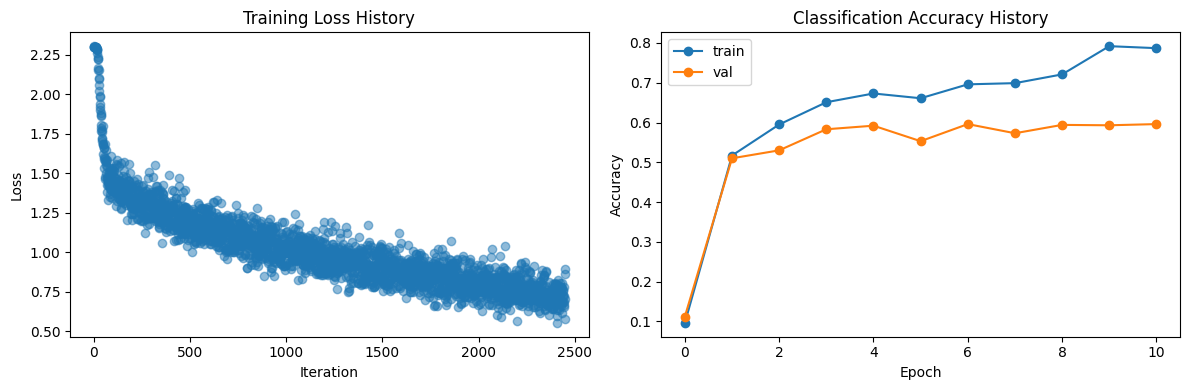

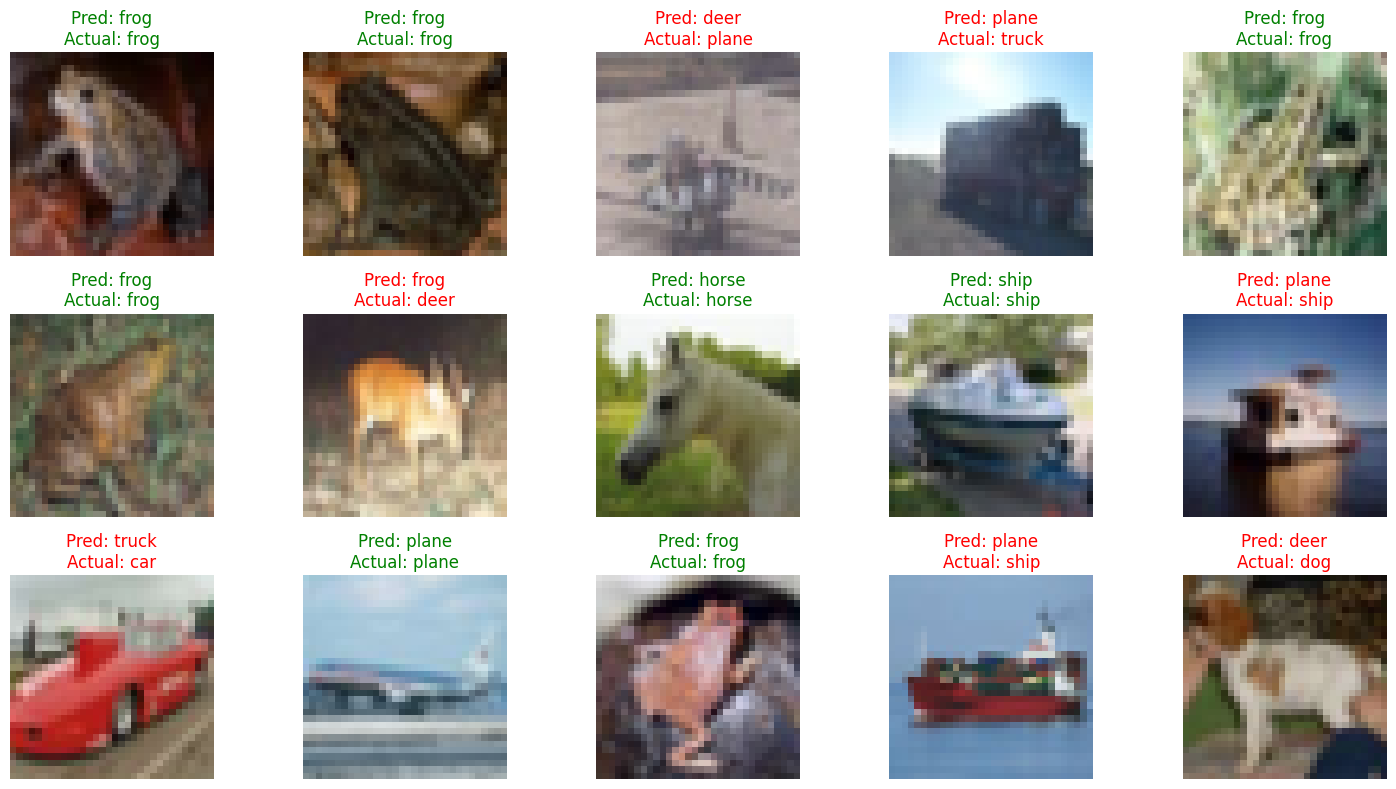

In [22]:
import matplotlib.pyplot as plt

# 1. Plot Training History (Loss and Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(solver.loss_history, 'o', alpha=0.5)
plt.title('Training Loss History')
plt.xlabel('Iteration')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.title('Classification Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Visualize Sample Predictions
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_samples = 15
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[idx].astype('uint8'))

    # Get prediction
    pred = y_test_pred[idx]
    actual = y_test[idx]

    color = 'green' if pred == actual else 'red'
    plt.title(f"Pred: {classes[pred]}\nActual: {classes[actual]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# **The Final Result**

**Softmax (Linear):** ~50% accuracy  
**Neural Network (Non-linear):** ~58% accuracy  

**The Winner:**  
The Neural Network won because it combined shape (HOG) and color features in ways a simple linear model could not.



### **What We Learned**

**Pixels are messy:**  
Features like HOG (edges) and Color Histograms are much more stable for a computer to interpret than raw pixel values.

**Learning rates matter:**  
Feature-based inputs require much higher learning rates (e.g., $0.1$ or $0.5$) compared to raw pixels to begin learning effectively.

**The ceiling of hand-crafted features:**  
Hand-designed features have an upper performance limit. Reaching ~90% accuracy will require convolutional neural networks (CNNs) to automatically learn richer features.
